# Day 21: Introduction to LangGraph Framework

Welcome to Day 21! Today we're learning **LangGraph** - a framework for building stable, resilient agent workflows using graph structures.

## What We'll Cover
1. Understanding LangGraph terminology (graphs, states, nodes, edges)
2. The five steps to build a graph
3. State immutability and reducers
4. Building a simple random response graph
5. Building a real chatbot with OpenAI
6. Visualizing graphs

Let's get started!


## Setup and Imports

First, let's import all the libraries we'll need and load our environment variables.

**Important**: Before running the cells below, make sure you have a `.env` file in the Day_21 folder with your OpenAI API key:

```
OPENAI_API_KEY=your_api_key_here
```

If you don't have a `.env` file yet, you can create one by running this in your terminal:

```bash
# Windows
echo OPENAI_API_KEY=your_api_key_here > .env

# Mac/Linux
echo "OPENAI_API_KEY=your_api_key_here" > .env
```

Or create it manually in a text editor.


In [1]:
# Standard library imports
import os
import random
from typing import Annotated

# Load environment variables
from dotenv import load_dotenv
load_dotenv()

# Pydantic for state management
from pydantic import BaseModel

# LangGraph imports
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

# LangChain for LLM integration
from langchain_openai import ChatOpenAI

# Gradio for UI
import gradio as gr

# For visualization
from IPython.display import Image, display

print("✓ All imports successful!")

# Check if API key is loaded
api_key = os.getenv('OPENAI_API_KEY')
if api_key:
    print(f"✓ OpenAI API Key loaded: {api_key[:20]}...")
else:
    print("⚠️ WARNING: OPENAI_API_KEY not found!")
    print("   Please create a .env file in this directory with:")
    print("   OPENAI_API_KEY=your_api_key_here")
    print("\n   You can still run the random response example (no API key needed)")
    print("   but the OpenAI chatbot example will not work.")


✓ All imports successful!
✓ OpenAI API Key loaded: sk-proj-TkT3TrT50WFH...


## Understanding Type Hints and Annotations

Before we dive into LangGraph, let's understand Python's `Annotated` type hints, which LangGraph uses extensively.


In [2]:
# Simple type hints
def shout(text: str) -> str:
    """Convert text to uppercase"""
    return text.upper()

# Test it
print(shout("hello"))

# Annotated type hints (with metadata)
def shout_annotated(text: Annotated[str, "something to be shouted"]) -> str:
    """Convert text to uppercase with annotation"""
    return text.upper()

# The annotation doesn't change behavior - it's metadata for other tools
print(shout_annotated("hello world"))

print("\n✓ Annotations are just metadata - Python ignores them!")


HELLO
HELLO WORLD

✓ Annotations are just metadata - Python ignores them!


## Example 1: Simple Random Response Graph

Let's build our first graph! This will generate random silly sentences (no LLM needed) to demonstrate the core concepts.

### Step 1: Define the State Class


In [3]:
# Define our state structure
class State(BaseModel):
    """State holds the conversation messages.
    
    The 'messages' field is annotated with add_messages reducer,
    which tells LangGraph how to combine message lists.
    """
    messages: Annotated[list, add_messages]

print("✓ State class defined!")
print("  - Has 'messages' field")
print("  - Uses 'add_messages' reducer to concatenate message lists")


✓ State class defined!
  - Has 'messages' field
  - Uses 'add_messages' reducer to concatenate message lists


### Step 2: Start the Graph Builder


In [4]:
# Initialize the graph builder with our State class
graph_builder = StateGraph(State)

print("✓ Graph builder initialized!")
print("  - Ready to add nodes and edges")


✓ Graph builder initialized!
  - Ready to add nodes and edges


### Step 3: Create a Node

Nodes are Python functions that:
1. Receive the current state
2. Do some work
3. Return a new state (immutable!)


In [5]:
# Constants for random sentence generation
NOUNS = ["Muffins", "Penguins", "Pickles", "Unicorns", "Dragons", "Robots"]
ADJECTIVES = ["haunted", "sparkly", "outrageous", "untrustworthy", "mysterious", "delightful"]

def random_response_node(old_state: State) -> State:
    """Generate a random silly sentence.
    
    This demonstrates that nodes don't need to use LLMs -
    they're just Python functions!
    """
    # Generate random sentence
    noun = random.choice(NOUNS)
    adjective = random.choice(ADJECTIVES)
    reply = f"{noun} are {adjective}"
    
    # Create a message in OpenAI format
    message = {"role": "assistant", "content": reply}
    
    # Return NEW state (don't modify old_state!)
    new_state = State(messages=[message])
    return new_state

# Add the node to our graph
graph_builder.add_node("random_responder", random_response_node)

print("✓ Node 'random_responder' created and added!")
print("  - Generates random silly sentences")
print("  - Takes old state, returns new state")


✓ Node 'random_responder' created and added!
  - Generates random silly sentences
  - Takes old state, returns new state


In [6]:
# Add edges to connect our workflow
# START -> random_responder -> END

graph_builder.add_edge(START, "random_responder")
graph_builder.add_edge("random_responder", END)

print("✓ Edges created!")
print("  - START → random_responder")
print("  - random_responder → END")


✓ Edges created!
  - START → random_responder
  - random_responder → END


### Step 5: Compile the Graph

Compilation transforms the builder into an executable graph.


In [7]:
# Compile the graph
random_graph = graph_builder.compile()

print("✓ Graph compiled!")
print("  - Ready to invoke")


✓ Graph compiled!
  - Ready to invoke


### Visualize the Graph

One of LangGraph's best features - visual representation!


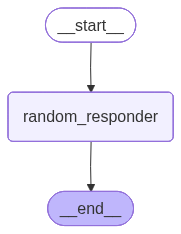


✓ Graph visualization displayed above!


In [8]:
# Display the graph structure
try:
    display(Image(random_graph.get_graph().draw_mermaid_png()))
    print("\n✓ Graph visualization displayed above!")
except Exception as e:
    print(f"Note: Visualization requires graphviz. Error: {e}")
    print("Graph structure: START → random_responder → END")


### Test the Random Response Graph

Now let's actually run it!


In [9]:
# Create initial state with a user message
initial_state = State(messages=[{"role": "user", "content": "Hi there!"}])

# Invoke the graph
result = random_graph.invoke(initial_state)

# Display the result
print("Result:")
print(result)
print("\nMessages:")
for msg in result['messages']:
    print(f"  - {msg}")


Result:
{'messages': [HumanMessage(content='Hi there!', additional_kwargs={}, response_metadata={}, id='7ecac342-7892-49f2-b46e-5c2d05b0a28b'), AIMessage(content='Robots are mysterious', additional_kwargs={}, response_metadata={}, id='a98fe906-f78c-41de-8fd9-9bc51c14d2bd', tool_calls=[], invalid_tool_calls=[])]}

Messages:
  - content='Hi there!' additional_kwargs={} response_metadata={} id='7ecac342-7892-49f2-b46e-5c2d05b0a28b'
  - content='Robots are mysterious' additional_kwargs={} response_metadata={} id='a98fe906-f78c-41de-8fd9-9bc51c14d2bd' tool_calls=[] invalid_tool_calls=[]


### Create a Gradio Interface

Let's make it interactive!


In [10]:
def random_chat(message, history):
    """Gradio chat function for random responses."""
    # Create state with user message
    state = State(messages=[{"role": "user", "content": message}])
    
    # Invoke graph
    result = random_graph.invoke(state)
    
    # Print full result for debugging
    print("\nFull result:")
    print(result)
    
    # Return the assistant's response
    return result['messages'][-1].content

# Create and launch interface
random_interface = gr.ChatInterface(
    random_chat,
    title="Random Response Bot",
    description="A silly bot that generates random sentences using LangGraph!"
)

random_interface.launch()


c:\Users\HP\.conda\envs\llm-env\Lib\site-packages\gradio\chat_interface.py:339: UserWarning: The 'tuples' format for chatbot messages is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style 'role' and 'content' keys.
  self.chatbot = Chatbot(


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


## Example 2: Real Chatbot with OpenAI

Now let's build a real chatbot that uses OpenAI's GPT model!

### Define State and Builder (Same as Before)


In [11]:
# We'll reuse the same State class
# Create a new graph builder
chatbot_graph_builder = StateGraph(State)

print("✓ New graph builder for chatbot created!")


✓ New graph builder for chatbot created!


### Initialize the LLM

We'll use LangChain's ChatOpenAI wrapper for convenience.


In [12]:
# Initialize OpenAI model
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.7,
    api_key=os.getenv("OPENAI_API_KEY")
)

print("✓ OpenAI LLM initialized!")
print(f"  - Model: gpt-4o-mini")
print(f"  - Temperature: 0.7")


✓ OpenAI LLM initialized!
  - Model: gpt-4o-mini
  - Temperature: 0.7


### Create Chatbot Node

This node will call the LLM with the message history.


In [13]:
def chatbot_node(old_state: State) -> State:
    """Call OpenAI with the message history.
    
    This demonstrates using a real LLM in a node.
    """
    # Call the LLM with all messages from state
    response = llm.invoke(old_state.messages)
    
    # Return new state with the response
    # The add_messages reducer will concatenate this with existing messages
    return State(messages=[response])

# Add node to graph
chatbot_graph_builder.add_node("chatbot", chatbot_node)

print("✓ Chatbot node created!")
print("  - Calls OpenAI LLM")
print("  - Returns response in new state")


✓ Chatbot node created!
  - Calls OpenAI LLM
  - Returns response in new state


### Add Edges and Compile


In [14]:
# Add edges
chatbot_graph_builder.add_edge(START, "chatbot")
chatbot_graph_builder.add_edge("chatbot", END)

# Compile
chatbot_graph = chatbot_graph_builder.compile()

print("✓ Chatbot graph compiled!")
print("  - START → chatbot → END")


✓ Chatbot graph compiled!
  - START → chatbot → END


### Visualize Chatbot Graph


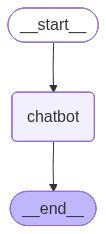


✓ Chatbot graph visualization displayed!


In [15]:
# Display the graph
try:
    display(Image(chatbot_graph.get_graph().draw_mermaid_png()))
    print("\n✓ Chatbot graph visualization displayed!")
except Exception as e:
    print(f"Note: Visualization requires graphviz. Error: {e}")
    print("Graph structure: START → chatbot → END")


### Test the Chatbot


In [16]:
# Test with a simple message
test_state = State(messages=[{"role": "user", "content": "Hello! How are you?"}])

result = chatbot_graph.invoke(test_state)

print("Conversation:")
for msg in result['messages']:
    role = msg.type if hasattr(msg, 'type') else 'unknown'
    content = msg.content if hasattr(msg, 'content') else str(msg)
    print(f"\n{role.upper()}: {content}")


Conversation:

HUMAN: Hello! How are you?

AI: Hello! I'm just a program, so I don't have feelings, but I'm here and ready to help you. How can I assist you today?


### Create Chatbot Gradio Interface


In [17]:
def chatbot_chat(message, history):
    """Gradio chat function for OpenAI chatbot."""
    # Create state with user message
    state = State(messages=[{"role": "user", "content": message}])
    
    # Invoke graph
    result = chatbot_graph.invoke(state)
    
    # Print full result for debugging
    print("\nFull result:")
    print(result)
    
    # Return the assistant's response
    return result['messages'][-1].content

# Create interface
chatbot_interface = gr.ChatInterface(
    chatbot_chat,
    title="LangGraph Chatbot",
    description="A real chatbot powered by OpenAI and LangGraph!"
)

chatbot_interface.launch()


c:\Users\HP\.conda\envs\llm-env\Lib\site-packages\gradio\chat_interface.py:339: UserWarning: The 'tuples' format for chatbot messages is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style 'role' and 'content' keys.
  self.chatbot = Chatbot(


* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


## Current Limitation: No Memory

Let's test if the chatbot remembers previous messages.


In [18]:
# First message
state1 = State(messages=[{"role": "user", "content": "My name is Alice"}])
result1 = chatbot_graph.invoke(state1)
print("User: My name is Alice")
print(f"Bot: {result1['messages'][-1].content}")

# Second message (new invocation)
state2 = State(messages=[{"role": "user", "content": "What's my name?"}])
result2 = chatbot_graph.invoke(state2)
print("\nUser: What's my name?")
print(f"Bot: {result2['messages'][-1].content}")

print("\n⚠️ The bot doesn't remember! Each invoke is independent.")
print("   We'll fix this in Day 22 with memory and checkpointing.")


User: My name is Alice
Bot: Nice to meet you, Alice! How can I assist you today?

User: What's my name?
Bot: I'm sorry, but I don't have access to personal information about individuals unless you've shared it with me in this conversation. What would you like me to call you?

⚠️ The bot doesn't remember! Each invoke is independent.
   We'll fix this in Day 22 with memory and checkpointing.


## Summary and Key Takeaways

### What We Learned Today

1. **LangGraph Basics**:
   - Graphs = tree structures for workflows
   - State = immutable snapshots
   - Nodes = Python functions that do work
   - Edges = connections that control flow

2. **Five Steps to Build a Graph**:
   1. Define State class
   2. Start Graph Builder
   3. Create Nodes
   4. Create Edges
   5. Compile Graph

3. **Key Concepts**:
   - State immutability (never modify, always create new)
   - Reducers (combine state updates safely)
   - Two phases: build graph → execute graph
   - Visualization helps understand workflows

4. **Current Limitation**:
   - No memory between invocations
   - Each call is independent
   - Fixed in Day 22 with checkpointing!

### What's Next (Day 22)

- Conversation memory and history
- Tool calling in nodes
- Conditional edges
- More complex workflows

### Practice Exercises

1. Modify the random response bot to use different word lists
2. Create a graph with multiple nodes in sequence
3. Add a system prompt to the chatbot
4. Experiment with different LLM parameters (temperature, model)

Great work today! See you in Day 22! 🚀
